<a href="https://colab.research.google.com/github/aysenuruyar-rgb/DSA210-Proj/blob/main/notebook/03_hypothesis_tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy import special

from os.path import join

import warnings
warnings.simplefilter('ignore')

final_data = pd.read_csv("final_dataset.csv", index_col=0)
final_data.head()

,GENERAL_DAM_OCCUPANCY_RATE,GENERAL_DAM_RESERVED_WATER,precipitation_sum (mm),temperature_2m_mean (°C),rain_sum (mm),snowfall_sum (cm)
2005-01-31,46.650000,405.258065,126.2,7.006452,125.6,0.77
2005-02-28,72.679286,631.285714,108.5,5.996429,87.7,14.91
2005-03-31,92.837097,806.419355,66.8,7.090323,56.7,7.28
2005-04-30,92.331667,802.100000,36.1,11.813333,36.1,0.00
2005-05-31,87.719677,762.032258,12.3,16.148387,12.3,0.00


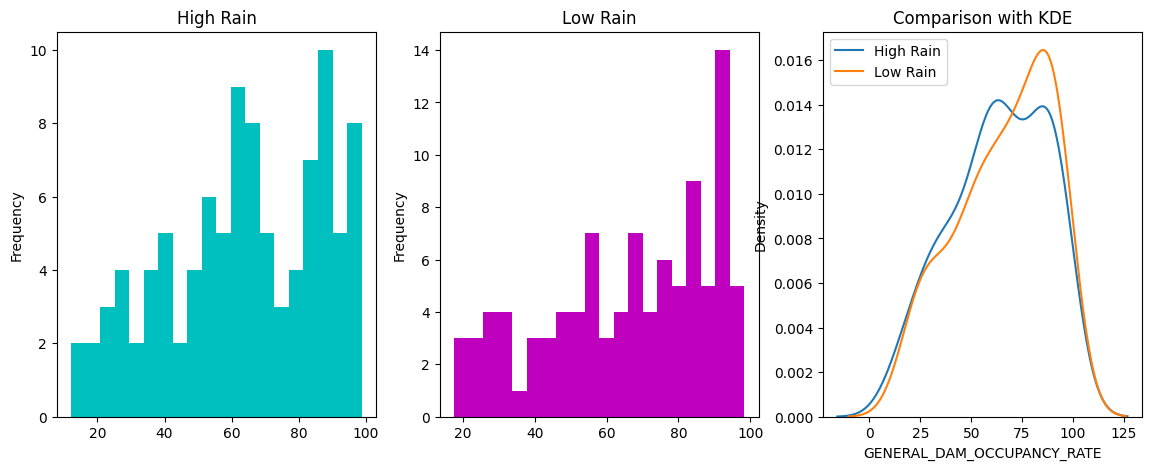

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(14,5))

# High rain histogram
high_rain["GENERAL_DAM_OCCUPANCY_RATE"].plot(
    kind="hist", ax=ax[0], bins=20, color="c"
)
ax[0].set_title("High Rain")

# Low rain histogram
low_rain["GENERAL_DAM_OCCUPANCY_RATE"].plot(
    kind="hist", ax=ax[1], bins=20, color="m"
)
ax[1].set_title("Low Rain")

# KDE comparison
sns.kdeplot(high_rain["GENERAL_DAM_OCCUPANCY_RATE"], ax=ax[2], label="High Rain")
sns.kdeplot(low_rain["GENERAL_DAM_OCCUPANCY_RATE"], ax=ax[2], label="Low Rain")

ax[2].set_title("Comparison with KDE")
ax[2].legend()

plt.show()

H0 (Null Hypothesis): Rainfall has no effect on dam occupancy.

H1 (Alternative Hypothesis): Rainfall affects dam occupancy.

In [ ]:
threshold = final_data["precipitation_sum (mm)"].median()

high_rain = final_data[final_data["precipitation_sum (mm)"] > threshold]
low_rain  = final_data[final_data["precipitation_sum (mm)"] <= threshold]

print(len(high_rain), len(low_rain))

high_dam = high_rain["GENERAL_DAM_OCCUPANCY_RATE"]
low_dam  = low_rain["GENERAL_DAM_OCCUPANCY_RATE"]



98 98


In [ ]:
t_stat, p_value = stats.ttest_ind(high_dam, low_dam, equal_var=False)

print("p-value:", p_value)

p-value: 0.4146080609332651


In [ ]:
if p_value < 0.05:
    print("Reject H0 → Rainfall affects dam occupancy")
else:
    print("Fail to reject H0 → No significant effect")

Fail to reject H0 → No significant effect


The results of the two-sample t-test show that there is no statistically significant difference in dam occupancy levels between high rainfall and low rainfall periods (p = 0.415). Therefore, we fail to reject the null hypothesis, suggesting that rainfall alone is not a sufficient factor in explaining reservoir levels.

This result is consistent with the exploratory data analysis, where no strong relationship was observed between rainfall and dam occupancy.

In [ ]:
X = final_data[[
    "precipitation_sum (mm)",
    "snowfall_sum (cm)",
    "temperature_2m_mean (°C)"
]]

y = final_data["GENERAL_DAM_OCCUPANCY_RATE"]

model = LinearRegression()
model.fit(X, y)

print("Coefficients:", model.coef_)
print("R^2:", model.score(X, y))

Coefficients: [-0.07536634  0.4491365  -0.3171522 ]
R^2: 0.02461557447037299


The regression results show that rainfall, snowfall, and temperature together explain only a small portion of the variation in dam occupancy (R² = 0.025). While temperature appears to have a slightly stronger (negative) effect compared to rainfall and snowfall, the overall explanatory power remains very low. This suggests that these environmental factors alone are not sufficient to explain reservoir levels.

H0: All seasons have the same mean dam occupancy.

H1: At least one season has a different mean dam occupancy.

In [ ]:
final_data["month"] = pd.to_datetime(final_data.index).month

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

final_data["season"] = final_data["month"].apply(get_season)

season_avg = final_data.groupby("season")["GENERAL_DAM_OCCUPANCY_RATE"].mean()

winter = final_data[final_data["season"] == "Winter"]["GENERAL_DAM_OCCUPANCY_RATE"]
spring = final_data[final_data["season"] == "Spring"]["GENERAL_DAM_OCCUPANCY_RATE"]
summer = final_data[final_data["season"] == "Summer"]["GENERAL_DAM_OCCUPANCY_RATE"]
fall   = final_data[final_data["season"] == "Fall"]["GENERAL_DAM_OCCUPANCY_RATE"]



f_stat, p_value = stats.f_oneway(winter, spring, summer, fall)

print("p-value:", p_value)


if p_value < 0.05:
    print("Reject H0 → Season has an effect")
else:
    print("Fail to reject H0 → No significant effect")

p-value: 6.215087387549809e-11
Reject H0 → Season has an effect


The test results show a highly significant difference in dam occupancy levels across seasons (p < 0.001). This confirms that seasonal patterns play a major role in determining reservoir levels.

While rainfall, snowfall, and temperature individually and collectively fail to explain dam occupancy levels, seasonal patterns show a strong and statistically significant effect. This indicates that reservoir levels are driven more by long-term seasonal dynamics than by short-term weather fluctuations.

Seasonality is a stronger determinant of dam occupancy than individual weather variables.


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression

df = pd.read_csv("featured_dataset.csv", index_col=0)
df.index = pd.to_datetime(df.index)

In [2]:
threshold = df["precipitation_sum (mm)"].median()

high = df[df["precipitation_sum (mm)"] > threshold]["GENERAL_DAM_OCCUPANCY_RATE"]
low  = df[df["precipitation_sum (mm)"] <= threshold]["GENERAL_DAM_OCCUPANCY_RATE"]

t_stat, p_value = stats.ttest_ind(high, low, equal_var=False)

print("p-value:", p_value)

p-value: 0.38136027183263466


We conducted a two-sample t-test to examine whether dam occupancy levels differ between high and low rainfall periods.

The p-value (p ≈ 0.38) is greater than the significance level of 0.05. Therefore, we fail to reject the null hypothesis.

This indicates that there is no statistically significant difference in dam occupancy between high and low rainfall periods. In other words, rainfall alone does not appear to have a significant effect on reservoir levels.

In [3]:
X = df[[
    "precipitation_sum (mm)",
    "snowfall_sum (cm)",
    "temperature_2m_mean (°C)"
]]

y = df["GENERAL_DAM_OCCUPANCY_RATE"]

model = LinearRegression()
model.fit(X, y)

print("R^2:", model.score(X, y))
print("Coefficients:", model.coef_)

R^2: 0.02140761984872619
Coefficients: [-0.07036361  0.41666288 -0.30269035]


A multiple linear regression model was used to assess the combined effect of rainfall, snowfall, and temperature on dam occupancy.

The model produced a very low R² value (~0.02), indicating that these variables explain only a small portion of the variance in dam occupancy.

Among the predictors, snowfall has a positive effect, while temperature has a negative effect. However, the overall explanatory power of the model is weak.

This suggests that short-term weather variables alone are not sufficient to explain changes in reservoir levels.

In [5]:
X = df[[
    "rain_lag_1",
    "rain_lag_3",
    "snow_lag_1",
    "temp_lag_1"
]]

y = df["GENERAL_DAM_OCCUPANCY_RATE"]

model = LinearRegression()
model.fit(X, y)

print("R^2 (lag model):", model.score(X, y))
print("Coefficients:", model.coef_)

R^2 (lag model): 0.23214210760602794
Coefficients: [ 0.0357967   0.21401357  0.57557918 -0.10563163]


To account for delayed effects of weather conditions, a lag-based regression model was constructed using lagged rainfall, snowfall, and temperature variables.

This model achieved a significantly higher R² value (~0.23), indicating a substantial improvement compared to the previous model.

The results suggest that past weather conditions have a stronger influence on dam occupancy than current values.

In particular, lagged snowfall appears to have a strong positive effect, highlighting the delayed contribution of snowmelt to reservoir levels.

This finding supports the idea that reservoir dynamics are influenced by cumulative and delayed environmental processes rather than immediate weather changes.

In [6]:
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Fall"

df["season"] = df["month"].apply(get_season)

winter = df[df["season"]=="Winter"]["GENERAL_DAM_OCCUPANCY_RATE"]
spring = df[df["season"]=="Spring"]["GENERAL_DAM_OCCUPANCY_RATE"]
summer = df[df["season"]=="Summer"]["GENERAL_DAM_OCCUPANCY_RATE"]
fall   = df[df["season"]=="Fall"]["GENERAL_DAM_OCCUPANCY_RATE"]

f_stat, p_value = stats.f_oneway(winter, spring, summer, fall)

print("p-value:", p_value)

p-value: 1.4464412210185454e-10


A one-way ANOVA test was conducted to determine whether dam occupancy differs across seasons.

The p-value (p ≈ 1.44e-10) is significantly below 0.05, leading us to reject the null hypothesis.

This indicates that there are statistically significant differences in dam occupancy between seasons.

Seasonal patterns therefore play a major role in determining reservoir levels, likely reflecting long-term climatic cycles rather than short-term weather fluctuations.

**FINAL FINDINGS**

Overall, the results suggest that while individual weather variables such as rainfall, snowfall, and temperature have limited explanatory power, temporal dynamics play a crucial role.

Lagged variables significantly improve model performance, indicating that past conditions influence current reservoir levels.

Moreover, strong seasonal effects confirm that dam occupancy is primarily driven by long-term climatic patterns rather than short-term fluctuations.

These findings highlight the importance of incorporating time-dependent features in modeling reservoir behavior.

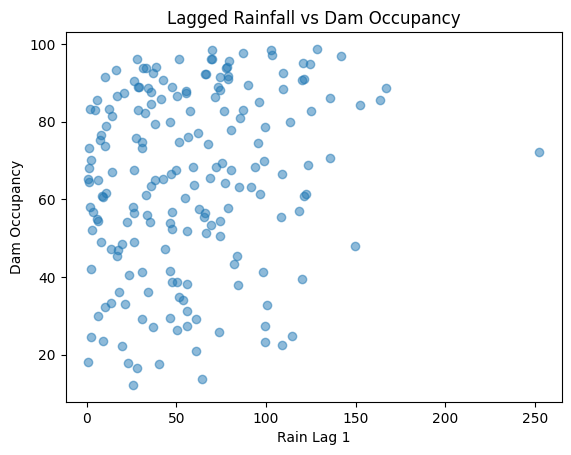

In [7]:
import matplotlib.pyplot as plt

plt.scatter(df["rain_lag_1"], df["GENERAL_DAM_OCCUPANCY_RATE"], alpha=0.5)
plt.xlabel("Rain Lag 1")
plt.ylabel("Dam Occupancy")
plt.title("Lagged Rainfall vs Dam Occupancy")
plt.show()